In [ ]:
%load_ext autoreload
%autoreload 2

import os
import json

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch_geometric.data import Batch, Data
# from torch_geometric.explain import Explainer, Explanation
# from torch_geometric.explain.config import ModelConfig
from torch_geometric.loader import DataLoader
from torch_geometric.utils import dense_to_sparse
from tqdm import tqdm

from dataset import ActionDataset
from datatools.defcon import DEFCON
from datatools.match_helper import MatchHelper
from datatools.trace_snapshot import TraceSnapshot
from datatools.xg_model import XGModel
from models.gat import GAT
from inference import find_active_players

### Calculating features and labels for the events in a match

In [ ]:
match_id = 10000
traces = pd.read_csv(f"data/2023 K League 1/traces/{match_id}.csv", header=0, index_col=0, low_memory=False)
events = pd.read_csv(f"data/2023 K League 1/events/{match_id}.csv", header=0)

xg_model = XGModel()
xg_model.train()

match = MatchHelper(traces, events)
match.construct_labels(xg_model=xg_model)
match.construct_graph_features()
match.features[0]

Calculating features per phase: 100%|████████████████████| 7/7 [00:03<00:00,  2.05it/s]


Data(x=[22, 18], edge_index=[2, 484], edge_attr=[484, 2])

### Estimating component probabilities by trained models

In [3]:
device = "cuda:2"
defcon = DEFCON(match, device=device)
defcon.estimate_components()

success: 100%|██████████| 720/720 [00:09<00:00, 72.66it/s]


In [ ]:
action_index = 185

frame = match.actions.at[action_index, "frame"]
frame_data = match.traces.loc[frame:frame].dropna(axis=1).copy()

passer = match.actions.at[action_index, "player_code"]
intent = match.actions.at[action_index, "intent"]
data_index = torch.argwhere(match.labels[:, 0] == action_index).item()
graph: Data = match.features[data_index]
edge_index = graph.edge_index.cpu().detach().numpy()

players = find_active_players(match, action_index)
src = [(players[0] + players[1])[i] for i in edge_index[0]]
dst = [(players[0] + players[1])[i] for i in edge_index[1]]
edges = np.array([src, dst]).T

passer, intent

('H23', 'H11')

### Visualizing receiver selection probabilities

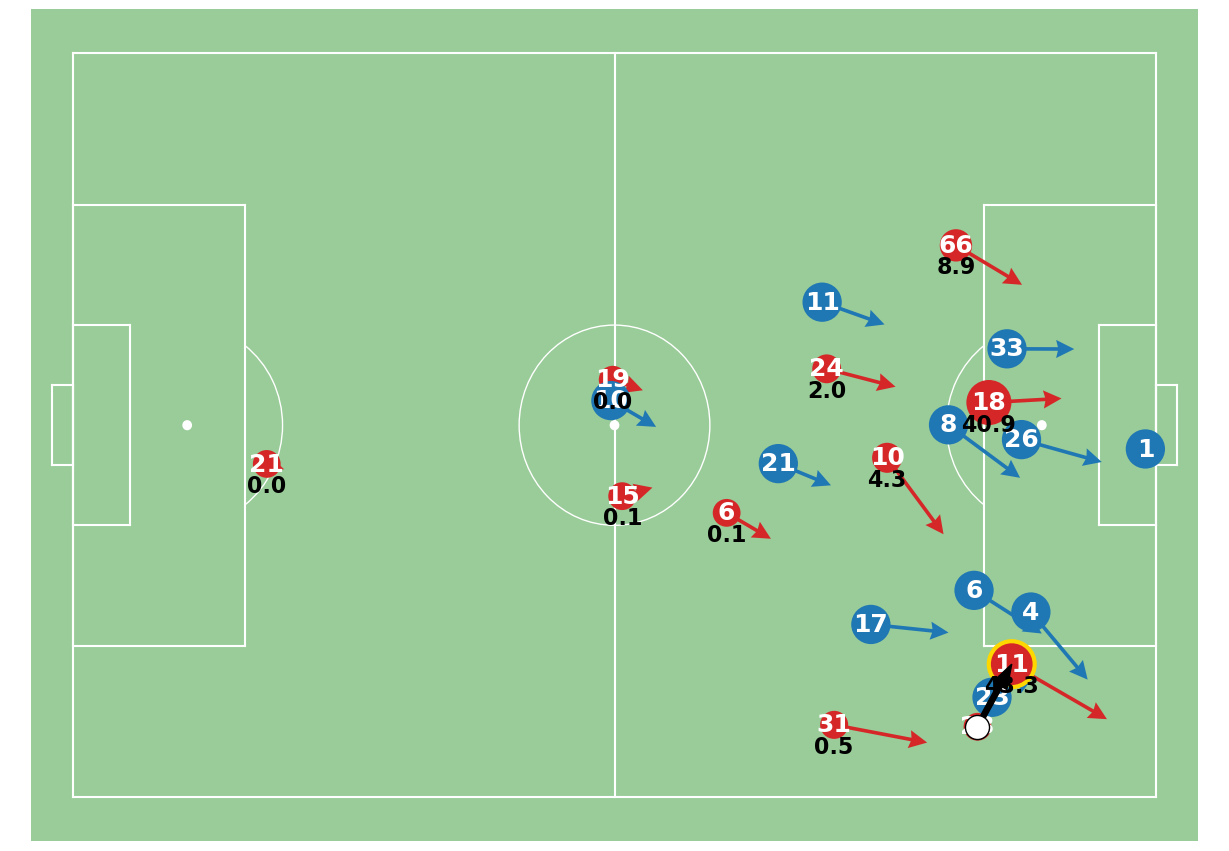

In [5]:
intent_probs_i = defcon.intent_probs.loc[action_index, players[0]].astype(float)
snapshot = TraceSnapshot(
    frame_data,
    player_sizes=intent_probs_i,
    player_annots=intent_probs_i.drop(passer),
    highlights={"gold": [intent]},
    arrows=[(passer, intent)],
)
snapshot.plot(max_color=0.5)

### Visualizing pass success probabilities

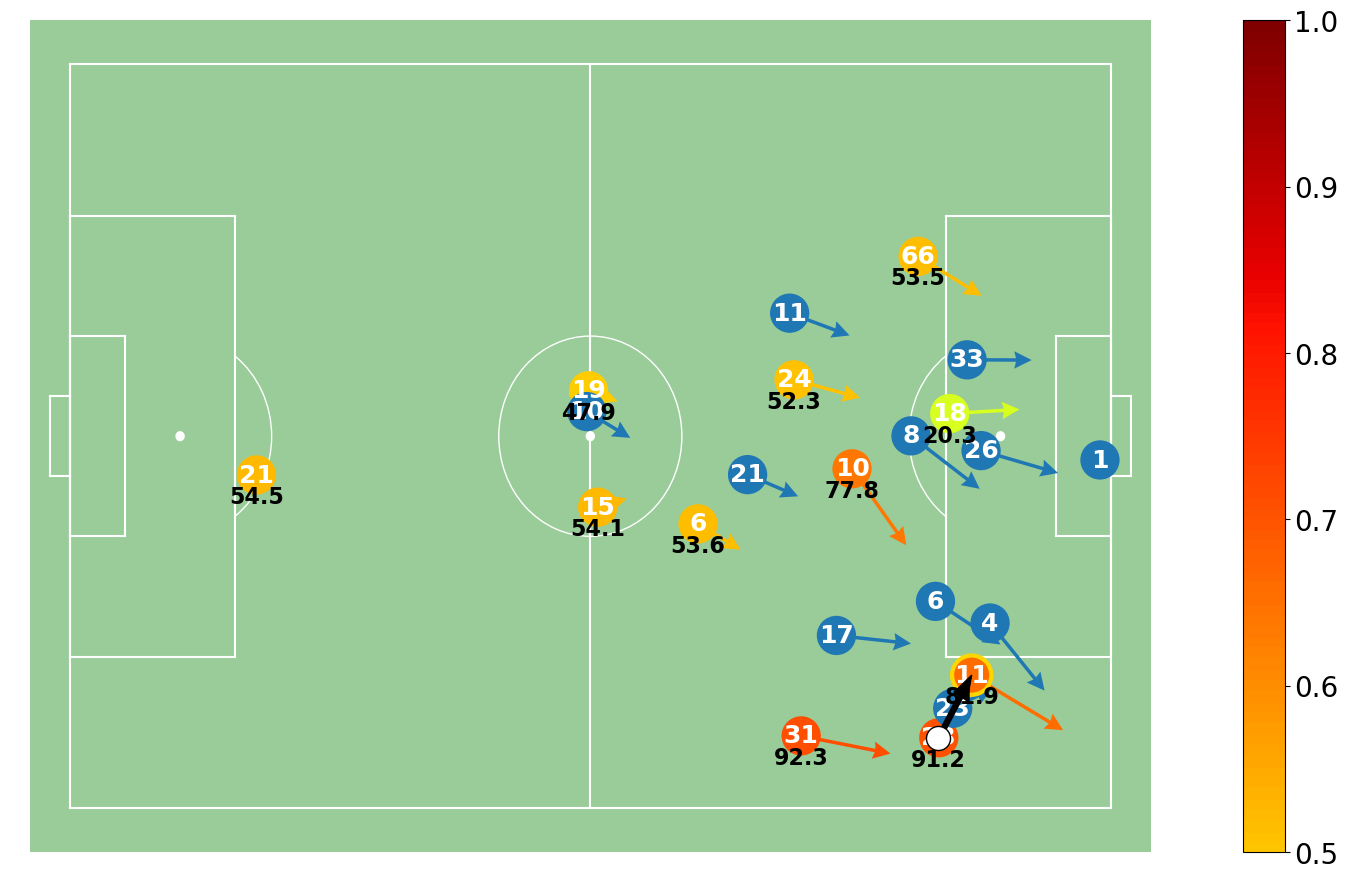

In [6]:
success_probs_i = defcon.success_probs.loc[action_index, players[0]]
snapshot = TraceSnapshot(
    frame_data,
    # player_sizes=intent_probs_i,
    player_colors=success_probs_i,
    player_annots=success_probs_i,
    highlights={"gold": [intent]},
    arrows=[(passer, intent)],
)
snapshot.plot(min_color=0.5, max_color=1)

### Visualizing success-conditioned goal probabilities

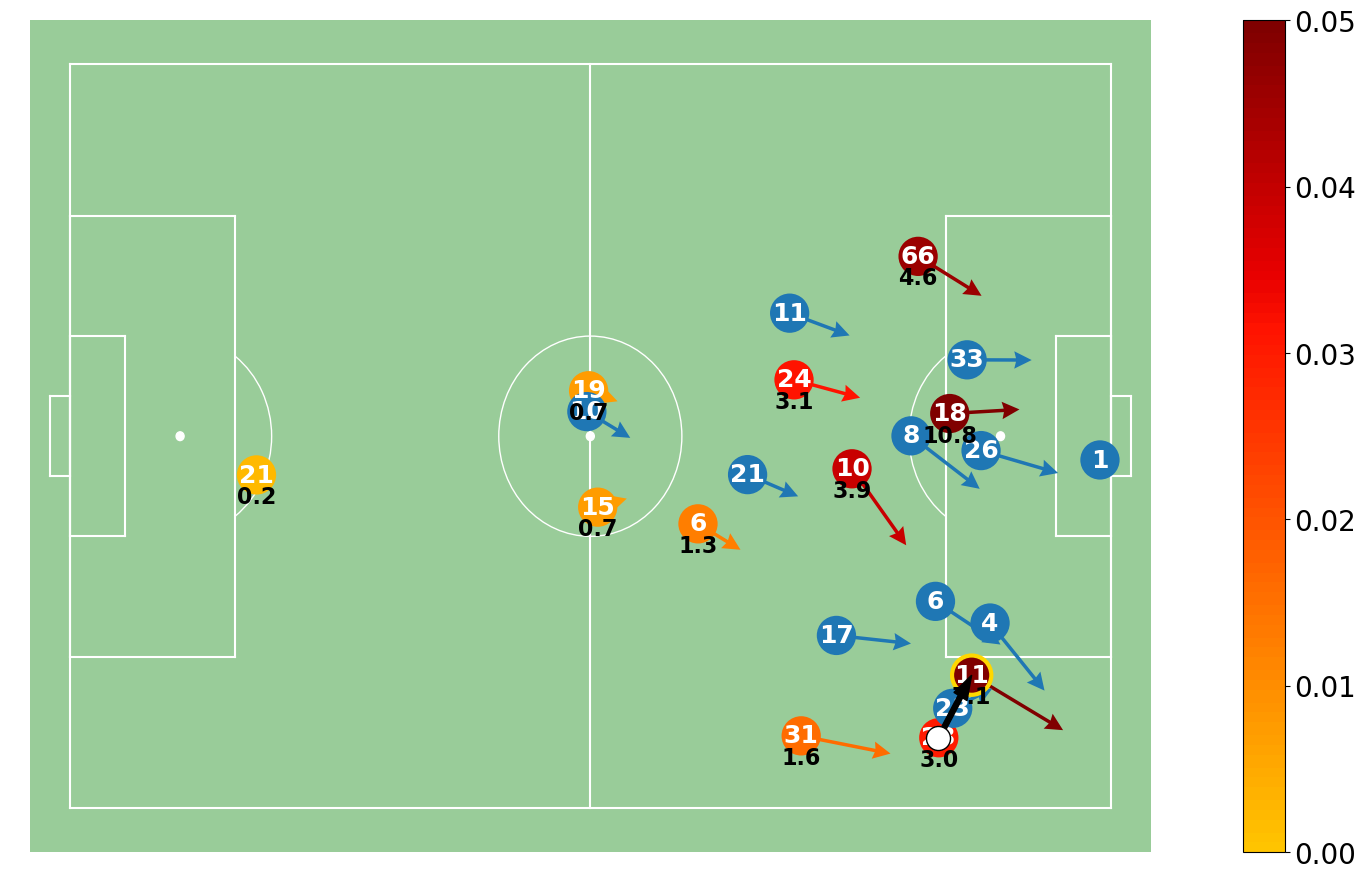

In [8]:
success_xreturns_i = defcon.success_xreturns.loc[action_index, players[0]].dropna().astype(float)
intent = match.actions.at[action_index, "intent"]
snapshot = TraceSnapshot(
    frame_data,
    # player_sizes=intent_probs_i,
    player_colors=success_xreturns_i,
    player_annots=success_xreturns_i,
    highlights={"gold": [intent]},
    arrows=[(passer, intent)],
)
snapshot.plot(min_color=0, max_color=0.05)

### Visualizing failure-conditioned goal probabilities

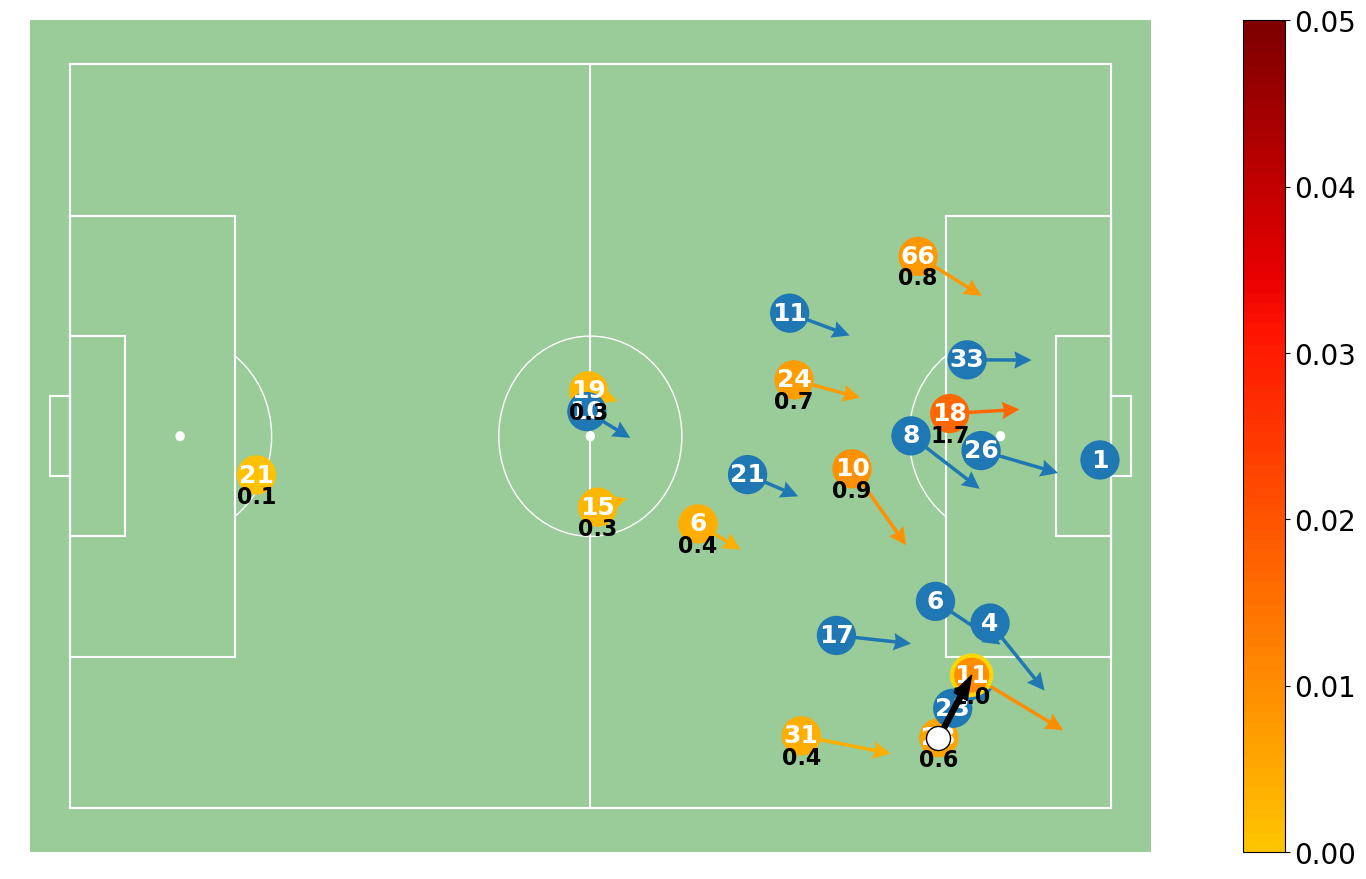

In [38]:
failure_xreturns_i = defcon.failure_xreturns.loc[action_index, players[0]].dropna().astype(float)
intent = match.actions.at[action_index, "intent"]
snapshot = TraceSnapshot(
    frame_data,
    # player_sizes=intent_probs_i,
    player_colors=failure_xreturns_i,
    player_annots=failure_xreturns_i,
    highlights={"gold": [intent]},
    arrows=[(passer, intent)],
)
snapshot.plot(min_color=0, max_color=0.05)

### Visualizing failure-conditioned interception probabilities

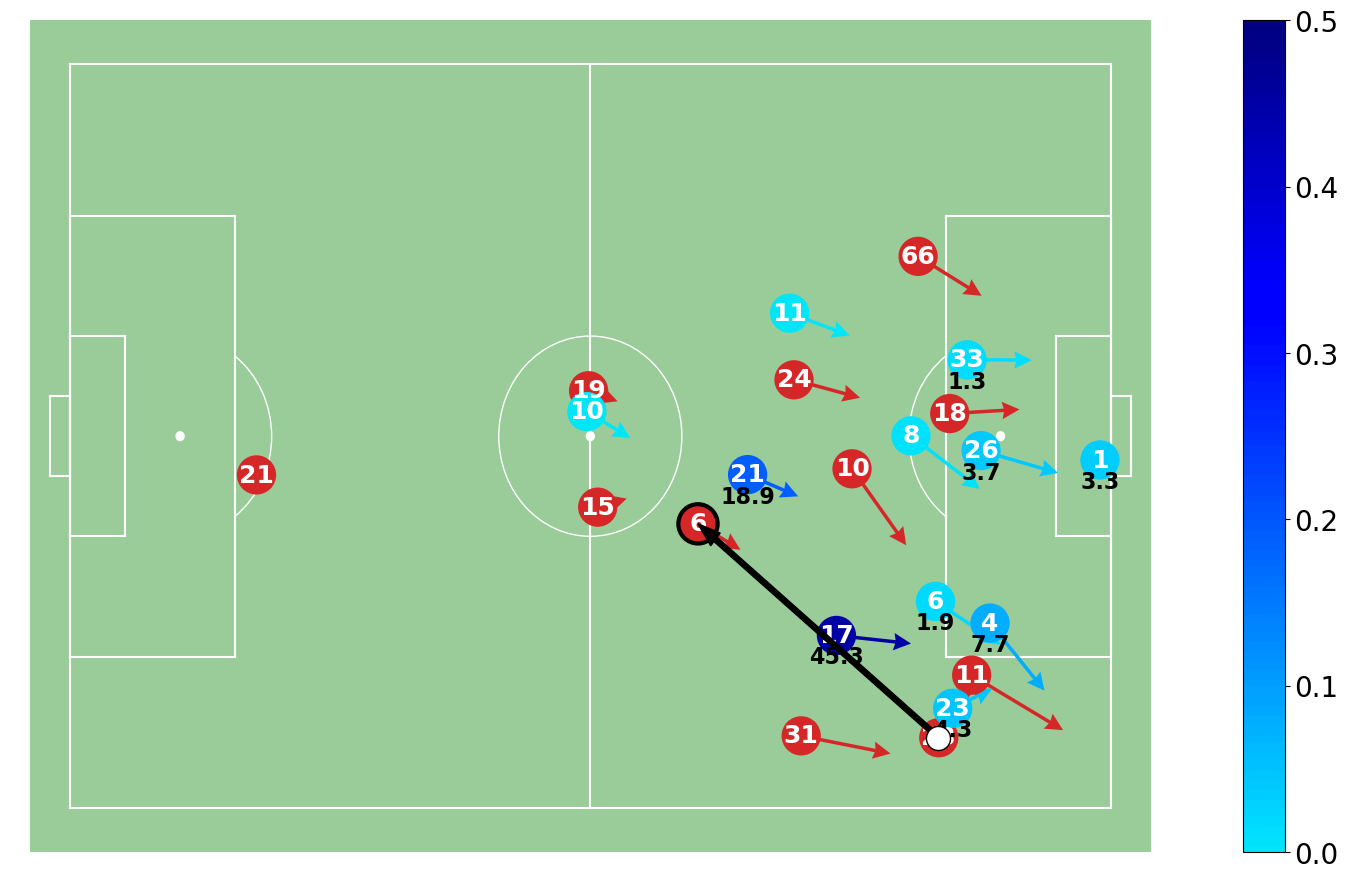

In [11]:
hypo_intent = 6
hypo_intent = f"{passer[0]}{hypo_intent:02d}"

intercept_probs_i = defcon.intercept_probs[defcon.intercept_probs["index"] == action_index].copy()
intercept_probs_i = intercept_probs_i.loc[hypo_intent].drop("index").dropna()

snapshot = TraceSnapshot(
    frame_data,
    player_colors=intercept_probs_i,
    player_annots=intercept_probs_i,
    highlights={"k": [hypo_intent]},
    # edges=edges,
    arrows=[(passer, hypo_intent)],
)
snapshot.plot(min_color=0, max_color=0.5, min_annot=0.01)